# Comment Category Prediction — v3 


## Key EDA Discoveries

| Label | Meaning | `if_2` (median) | `if_1==0` rate |
|---|---|---|---|
| 0 | Normal comment | **4** | 79.3% |
| 1 | Hate speech (racial/gender bias) | **10** | 17.0% ← very different! |
| 2 | Hostile/inflammatory | **10** | 76.6% |
| 3 | Borderline political | **10** | 79.6% |



In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import f1_score, classification_report
import lightgbm as lgb
from scipy.sparse import hstack
import matplotlib.pyplot as plt

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

try:
    import subprocess
    subprocess.run(['nvidia-smi'], capture_output=True)
    USE_GPU = True
    print('✅ GPU available!')
except:
    USE_GPU = False
    print('⚠️ CPU mode')

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv
✅ GPU available!


In [2]:
train  = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
test   = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/test.csv')
sample = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/Sample.csv')
print(f'Train: {train.shape} | Test: {test.shape}')
print(train['label'].value_counts(normalize=True).sort_index())

Train: (198000, 15) | Test: (102000, 14)
label
0    0.576631
1    0.080394
2    0.315354
3    0.027621
Name: proportion, dtype: float64


In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# FEATURE ENGINEERING  — EDA-informed v3
# ══════════════════════════════════════════════════════════════════════════════

def engineer_features(df, is_train=True, post_id_stats=None, label_enc=None):
    df = df.copy()
    df['comment'] = df['comment'].fillna('')

    # ═══════════════════════════════════════════════════════════════════
    # GROUP A: if_2 & if_1 — THE MOST POWERFUL FEATURES
    # EDA showed: if_2==4 → Label 0; if_2==10 → Labels 1/2/3
    # ═══════════════════════════════════════════════════════════════════

    # Exact binary flags (the core discriminators)
    df['if2_is_4']  = (df['if_2'] == 4).astype(int)   # Label 0 indicator
    df['if2_is_10'] = (df['if_2'] == 10).astype(int)  # Labels 1/2/3 indicator
    df['if2_is_5']  = (df['if_2'] == 5).astype(int)
    df['if2_is_6']  = (df['if_2'] == 6).astype(int)

    # if_2 log and direct (high outliers exist)
    df['log_if2']    = np.log1p(df['if_2'])
    df['if2_gt_10']  = (df['if_2'] > 10).astype(int)

    # if_1 — Strong for Label 1: Label1 has only 17% if_1==0 vs 79% for Label 0
    df['if1_is_0']  = (df['if_1'] == 0).astype(int)   # NOT label 1 signal
    df['if1_is_4']  = (df['if_1'] == 4).astype(int)   # Strong label 1 signal
    df['if1_is_10'] = (df['if_1'] == 10).astype(int)
    df['if1_is_6']  = (df['if_1'] == 6).astype(int)
    df['log_if1']   = np.log1p(df['if_1'])
    df['if1_nonzero'] = (df['if_1'] > 0).astype(int)  # 83% of Label 1!

    # Combined: the two most discriminative combinations
    df['if2_4_if1_0']   = ((df['if_2'] == 4)  & (df['if_1'] == 0)).astype(int)  # → Label 0
    df['if2_10_if1_nz'] = ((df['if_2'] == 10) & (df['if_1'] > 0)).astype(int)   # → Label 1
    df['if_sum']         = df['if_1'] + df['if_2']
    df['log_if_sum']     = np.log1p(df['if_sum'])

    # ═══════════════════════════════════════════════════════════════════
    # GROUP B: Identity columns — race values discriminate Label 1!
    # Label 1 (hate speech): 20.3% black, 25.3% white vs ~4% for Label 0
    # ═══════════════════════════════════════════════════════════════════

    # NaN indicators
    df['race_is_nan']    = df['race'].isna().astype(int)  # 73.5% NaN overall
    df['religion_is_nan']= df['religion'].isna().astype(int)
    df['gender_is_nan']  = df['gender'].isna().astype(int)
    df['all_id_nan']     = (df['race_is_nan'] & df['religion_is_nan'] & df['gender_is_nan']).astype(int)
    df['n_id_nans']      = df['race_is_nan'] + df['religion_is_nan'] + df['gender_is_nan']

    # Fill NaN before specific value checks
    df['race']     = df['race'].fillna('__nan__')
    df['religion'] = df['religion'].fillna('__nan__')
    df['gender']   = df['gender'].fillna('__nan__')

    # Race-specific flags (EDA: Label 1 has 20.3% black + 25.3% white!)
    df['race_black']   = (df['race'] == 'black').astype(int)
    df['race_white']   = (df['race'] == 'white').astype(int)
    df['race_asian']   = (df['race'] == 'asian').astype(int)
    df['race_latino']  = (df['race'] == 'latino').astype(int)
    df['race_none']    = (df['race'] == 'none').astype(int)    # detected but benign
    df['race_nonzero'] = (df['race'].isin(['black','white','asian','latino','other'])).astype(int)

    # Religion-specific flags
    df['religion_muslim']    = (df['religion'] == 'muslim').astype(int)
    df['religion_christian'] = (df['religion'] == 'christian').astype(int)
    df['religion_jewish']    = (df['religion'] == 'jewish').astype(int)
    df['religion_nonzero']   = (df['religion'].isin(['muslim','christian','jewish','atheist','buddhist','hindu','other'])).astype(int)

    # Gender-specific flags
    df['gender_female']      = (df['gender'] == 'female').astype(int)
    df['gender_male']        = (df['gender'] == 'male').astype(int)
    df['gender_transgender'] = (df['gender'] == 'transgender').astype(int)
    df['gender_nonzero']     = (df['gender'].isin(['female','male','transgender','other'])).astype(int)

    # Any identity mention detected (non-null AND not 'none')
    df['any_identity_mentioned'] = (df['race_nonzero'] | df['religion_nonzero'] | df['gender_nonzero']).astype(int)

    # Powerhouse combo: if2==10 + race mention → Label 1 signal
    df['if2_10_race_nz'] = ((df['if_2'] == 10) & (df['race_nonzero'] == 1)).astype(int)

    df['disability'] = df['disability'].astype(int)

    # Label-encode the full categorical values
    for col in ['race', 'religion', 'gender']:
        if label_enc and col in label_enc:
            le = label_enc[col]
            df[f'{col}_enc'] = df[col].map(
                lambda x, le=le: le.transform([x])[0] if x in le.classes_ else -1
            )
        else:
            le = LabelEncoder()
            df[f'{col}_enc'] = le.fit_transform(df[col].astype(str))
            if label_enc is not None:
                label_enc[col] = le

    # ═══════════════════════════════════════════════════════════════════
    # GROUP C: Engagement
    # ═══════════════════════════════════════════════════════════════════
    df['log_upvote']      = np.log1p(df['upvote'])
    df['log_downvote']    = np.log1p(df['downvote'])
    df['total_votes']     = df['upvote'] + df['downvote']
    df['log_total_votes'] = np.log1p(df['total_votes'])
    df['vote_ratio']      = df['upvote'] / (df['total_votes'] + 1)
    df['controversy']     = df['downvote'] / (df['upvote'] + 1)

    # ═══════════════════════════════════════════════════════════════════
    # GROUP D: Text stats (topped the FI plot — useful for within-class splits)
    # Note: similar MEANS across labels but trees still exploit the tails!
    # ═══════════════════════════════════════════════════════════════════
    df['char_count']       = df['comment'].str.len()
    df['word_count']       = df['comment'].str.split().str.len().fillna(0).astype(int)
    df['avg_word_len']     = df['char_count'] / (df['word_count'] + 1)
    df['unique_words']     = df['comment'].apply(lambda x: len(set(str(x).lower().split())))
    df['unique_ratio']     = df['unique_words'] / (df['word_count'] + 1)
    df['caps_ratio']       = df['comment'].str.count(r'[A-Z]') / (df['char_count'] + 1)
    df['caps_word_cnt']    = df['comment'].apply(
        lambda x: sum(1 for w in str(x).split() if w.isupper() and len(w) > 1)
    )
    df['special_char_cnt'] = df['comment'].str.count(r'[^\w\s]')
    df['exclamation_cnt']  = df['comment'].str.count('!')
    df['question_cnt']     = df['comment'].str.count(r'\?')
    df['digit_cnt']        = df['comment'].str.count(r'\d')
    df['sentence_cnt']     = df['comment'].str.count(r'[.!?]') + 1
    df['avg_sent_len']     = df['word_count'] / (df['sentence_cnt'] + 1)
    df['ellipsis_cnt']     = df['comment'].str.count(r'\.{3}')
    df['url_cnt']          = df['comment'].str.count(r'http|www\.')

    # ═══════════════════════════════════════════════════════════════════
    # GROUP E: Temporal with cyclical encoding
    # ═══════════════════════════════════════════════════════════════════
    df['created_date'] = pd.to_datetime(df['created_date'], utc=True)
    df['hour']         = df['created_date'].dt.hour
    df['day_of_week']  = df['created_date'].dt.dayofweek
    df['month']        = df['created_date'].dt.month
    df['year']         = df['created_date'].dt.year
    df['is_weekend']   = (df['day_of_week'] >= 5).astype(int)
    df['hour_sin']     = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos']     = np.cos(2 * np.pi * df['hour'] / 24)
    df['dow_sin']      = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['dow_cos']      = np.cos(2 * np.pi * df['day_of_week'] / 7)
    df['month_sin']    = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos']    = np.cos(2 * np.pi * df['month'] / 12)

    # ═══════════════════════════════════════════════════════════════════
    # GROUP F: Emoticons & post_id
    # ═══════════════════════════════════════════════════════════════════
    df['emoticon_sum'] = df['emoticon_1'] + df['emoticon_2'] + df['emoticon_3']
    df['has_emoticon'] = (df['emoticon_sum'] > 0).astype(int)

    if is_train:
        global_mean = df['label'].mean() if 'label' in df.columns else 0.794
        alpha = 10
        stats = df.groupby('post_id')['label'].agg(['mean', 'count'])
        stats['smoothed'] = (stats['mean'] * stats['count'] + global_mean * alpha) / (stats['count'] + alpha)
        post_id_stats = stats['smoothed'].to_dict()
    df['post_id_encoded'] = df['post_id'].map(post_id_stats).fillna(
        np.mean(list(post_id_stats.values()))
    )

    # ── Final feature list ──────────────────────────────────────────────────
    feature_cols = [
        # ★ if_2 exact value flags (most powerful!)
        'if_2', 'log_if2', 'if2_is_4', 'if2_is_10', 'if2_is_5', 'if2_is_6', 'if2_gt_10',
        # ★ if_1 exact value flags
        'if_1', 'log_if1', 'if1_is_0', 'if1_is_4', 'if1_is_10', 'if1_is_6', 'if1_nonzero',
        # ★ Combined if_1 + if_2 signals
        'if2_4_if1_0', 'if2_10_if1_nz', 'if_sum', 'log_if_sum',
        # ★ Race specific (key for Label 1)
        'race_is_nan', 'race_black', 'race_white', 'race_asian', 'race_latino', 'race_none', 'race_nonzero',
        # ★ Religion specific
        'religion_is_nan', 'religion_muslim', 'religion_christian', 'religion_jewish', 'religion_nonzero',
        # ★ Gender specific
        'gender_is_nan', 'gender_female', 'gender_male', 'gender_transgender', 'gender_nonzero',
        # Combined identity signals
        'all_id_nan', 'n_id_nans', 'any_identity_mentioned', 'if2_10_race_nz',
        'race_enc', 'religion_enc', 'gender_enc',
        'disability',
        # Engagement
        'upvote', 'downvote', 'log_upvote', 'log_downvote',
        'total_votes', 'log_total_votes', 'vote_ratio', 'controversy',
        # Text stats
        'char_count', 'word_count', 'avg_word_len', 'unique_words', 'unique_ratio',
        'caps_ratio', 'caps_word_cnt', 'special_char_cnt',
        'exclamation_cnt', 'question_cnt', 'digit_cnt',
        'sentence_cnt', 'avg_sent_len', 'ellipsis_cnt', 'url_cnt',
        # Temporal + cyclical
        'hour', 'day_of_week', 'month', 'year', 'is_weekend',
        'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos',
        # Emoticons + post_id
        'emoticon_1', 'emoticon_2', 'emoticon_3', 'emoticon_sum', 'has_emoticon',
        'post_id', 'post_id_encoded',
    ]

    return df, feature_cols, post_id_stats


label_enc = {}
train_fe, feature_cols, post_id_stats = engineer_features(train, is_train=True, label_enc=label_enc)
test_fe,  _,            _             = engineer_features(test,  is_train=False,
                                                           post_id_stats=post_id_stats,
                                                           label_enc=label_enc)

print(f'Total structured features: {len(feature_cols)}')

# Quick sanity check on key features
print('\n=== Sanity check: if2==4 by label ===')
print(train_fe.groupby('label')['if2_is_4'].mean())
print('\n=== Sanity check: if1_nonzero by label ===')
print(train_fe.groupby('label')['if1_nonzero'].mean())
print('\n=== Sanity check: race_nonzero by label ===')
print(train_fe.groupby('label')['race_nonzero'].mean())

Total structured features: 84

=== Sanity check: if2==4 by label ===
label
0    0.786683
1    0.004146
2    0.028379
3    0.012799
Name: if2_is_4, dtype: float64

=== Sanity check: if1_nonzero by label ===
label
0    0.207203
1    0.829752
2    0.233728
3    0.204425
Name: if1_nonzero, dtype: float64

=== Sanity check: race_nonzero by label ===
label
0    0.026723
1    0.444151
2    0.041976
3    0.027976
Name: race_nonzero, dtype: float64


In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# TF-IDF → TruncatedSVD(200) — dense text embeddings for LightGBM
# ══════════════════════════════════════════════════════════════════════════════

print('Building TF-IDF + SVD text features...')

tfidf_word = TfidfVectorizer(
    ngram_range  = (1, 2),
    max_features = 50_000,
    lowercase    = True,
    strip_accents= 'unicode',
    analyzer     = 'word',
    min_df       = 2,
    sublinear_tf = True,
)
tfidf_char = TfidfVectorizer(
    ngram_range  = (2, 4),
    max_features = 25_000,
    lowercase    = True,
    analyzer     = 'char_wb',
    min_df       = 3,
    sublinear_tf = True,
)

tfidf_word.fit(train_fe['comment'])
tfidf_char.fit(train_fe['comment'])

X_text_train = hstack([tfidf_word.transform(train_fe['comment']),
                        tfidf_char.transform(train_fe['comment'])])
X_text_test  = hstack([tfidf_word.transform(test_fe['comment']),
                        tfidf_char.transform(test_fe['comment'])])

print(f'TF-IDF matrix: {X_text_train.shape}')

print('Running TruncatedSVD(200)...')
SVD_N = 200
svd = TruncatedSVD(n_components=SVD_N, random_state=42, n_iter=5)
X_svd_train = svd.fit_transform(X_text_train)
X_svd_test  = svd.transform(X_text_test)
print(f'SVD explained variance: {svd.explained_variance_ratio_.sum():.1%}')

# Combine: structured + SVD text
X_struct_train = train_fe[feature_cols].values.astype(np.float32)
X_struct_test  = test_fe[feature_cols].values.astype(np.float32)

X_full_train = np.hstack([X_struct_train, X_svd_train.astype(np.float32)])
X_full_test  = np.hstack([X_struct_test,  X_svd_test.astype(np.float32)])

print(f'Combined matrix: {X_full_train.shape}  ({len(feature_cols)} structured + {SVD_N} SVD)')

Building TF-IDF + SVD text features...
TF-IDF matrix: (198000, 75000)
Running TruncatedSVD(200)...
SVD explained variance: 16.4%
Combined matrix: (198000, 284)  (84 structured + 200 SVD)


In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# LightGBM GPU — 5-fold Stratified CV
# ══════════════════════════════════════════════════════════════════════════════

y = train['label'].values
n_classes = 4

lgb_params = dict(
    objective          = 'multiclass',
    num_class          = n_classes,
    metric             = 'multi_logloss',
    n_estimators       = 3000,
    learning_rate      = 0.05,
    num_leaves         = 255,
    max_depth          = -1,
    min_child_samples  = 15,
    feature_fraction   = 0.7,
    bagging_fraction   = 0.8,
    bagging_freq       = 5,
    reg_alpha          = 0.05,
    reg_lambda         = 0.1,
    class_weight       = 'balanced',
    random_state       = 42,
    n_jobs             = -1,
    verbose            = -1,
    device             = 'gpu' if USE_GPU else 'cpu',
)

N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

oof_lgb  = np.zeros((len(train), n_classes))
test_lgb = np.zeros((len(test),  n_classes))
fold_scores = []
best_iters  = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_full_train, y)):
    print(f'\n── Fold {fold+1}/{N_FOLDS} ──')
    Xtr, Xval = X_full_train[tr_idx], X_full_train[val_idx]
    ytr, yval = y[tr_idx], y[val_idx]

    model = lgb.LGBMClassifier(**lgb_params)
    model.fit(
        Xtr, ytr,
        eval_set=[(Xval, yval)],
        callbacks=[
            lgb.early_stopping(150, verbose=False),
            lgb.log_evaluation(500),
        ]
    )

    oof_lgb[val_idx] = model.predict_proba(Xval)
    test_lgb        += model.predict_proba(X_full_test) / N_FOLDS
    best_iters.append(model.best_iteration_)

    score = f1_score(yval, oof_lgb[val_idx].argmax(1), average='macro')
    fold_scores.append(score)
    print(f'  macro F1 = {score:.5f}  (best_iter={model.best_iteration_})')

lgb_oof_score = f1_score(y, oof_lgb.argmax(1), average='macro')
print(f'\n✅ LightGBM OOF macro F1: {lgb_oof_score:.5f} ± {np.std(fold_scores):.5f}')
print('\nClassification Report:')
print(classification_report(y, oof_lgb.argmax(1)))


── Fold 1/5 ──


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


  macro F1 = 0.73536  (best_iter=198)

── Fold 2/5 ──
  macro F1 = 0.75064  (best_iter=203)

── Fold 3/5 ──
  macro F1 = 0.74726  (best_iter=197)

── Fold 4/5 ──
  macro F1 = 0.74631  (best_iter=196)

── Fold 5/5 ──
  macro F1 = 0.74950  (best_iter=197)

✅ LightGBM OOF macro F1: 0.74583 ± 0.00545

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.95      0.96    114173
           1       0.71      0.77      0.74     15918
           2       0.83      0.86      0.85     62440
           3       0.61      0.35      0.44      5469

    accuracy                           0.89    198000
   macro avg       0.78      0.73      0.75    198000
weighted avg       0.89      0.89      0.89    198000



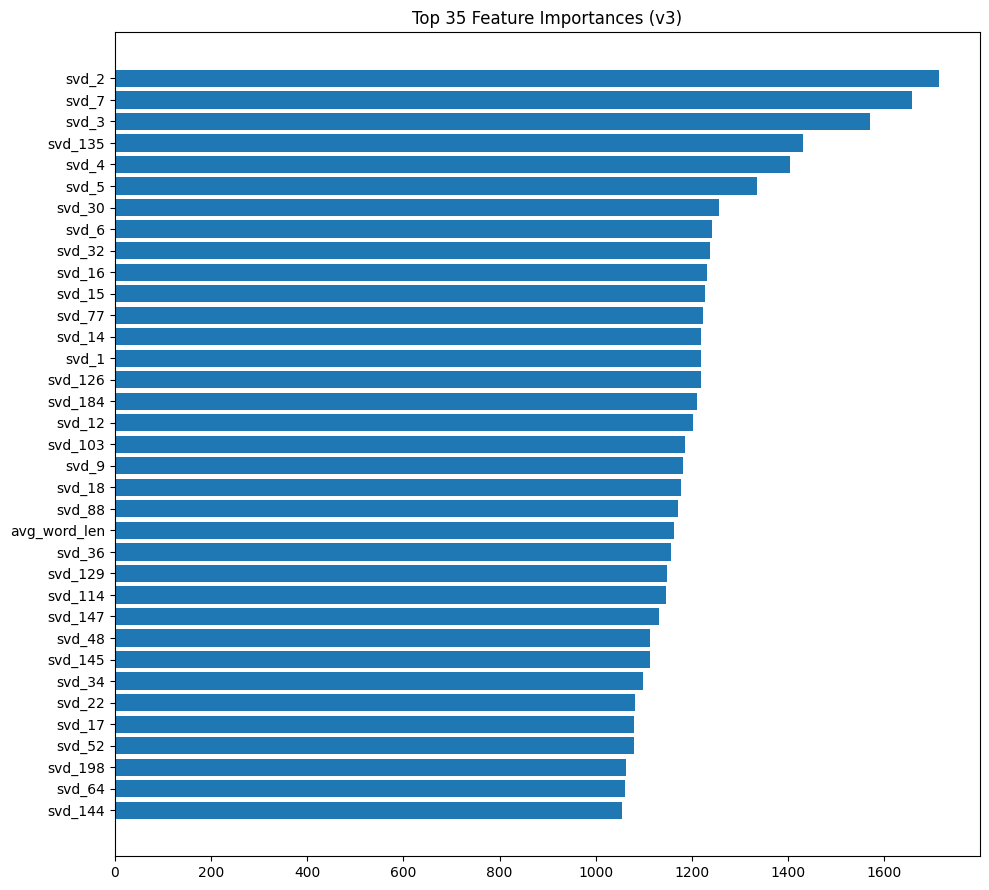

Top 10 features:
     feature  importance
86     svd_2        1713
91     svd_7        1658
87     svd_3        1570
219  svd_135        1430
88     svd_4        1403
89     svd_5        1336
114   svd_30        1255
90     svd_6        1242
116   svd_32        1238
100   svd_16        1232

SVD features in top 35: 34


In [6]:
# ── Feature Importance ────────────────────────────────────────────────────────
all_feat_names = feature_cols + [f'svd_{i}' for i in range(SVD_N)]
fi = pd.DataFrame({'feature': all_feat_names,
                   'importance': model.feature_importances_}).sort_values(
    'importance', ascending=False
)

plt.figure(figsize=(10, 9))
plt.barh(fi['feature'].head(35)[::-1], fi['importance'].head(35)[::-1])
plt.title('Top 35 Feature Importances (v3)')
plt.tight_layout()
plt.show()

print('Top 10 features:')
print(fi.head(10)[['feature','importance']].to_string())
print(f"\nSVD features in top 35: {fi.head(35)['feature'].str.startswith('svd_').sum()}")

In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# Fast LR on SVD(200) — text specialist
# ══════════════════════════════════════════════════════════════════════════════

print('Training LR on SVD(200) text features...')
scaler = StandardScaler()
X_svd_train_s = scaler.fit_transform(X_svd_train)
X_svd_test_s  = scaler.transform(X_svd_test)

oof_lr  = np.zeros((len(train), n_classes))
test_lr = np.zeros((len(test),  n_classes))
lr_scores = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_full_train, y)):
    lr = LogisticRegression(
        C=3.0, max_iter=1000, solver='lbfgs',
        class_weight='balanced', random_state=42,
        multi_class='multinomial', n_jobs=-1
    )
    lr.fit(X_svd_train_s[tr_idx], y[tr_idx])
    oof_lr[val_idx] = lr.predict_proba(X_svd_train_s[val_idx])
    test_lr        += lr.predict_proba(X_svd_test_s) / N_FOLDS
    score = f1_score(y[val_idx], oof_lr[val_idx].argmax(1), average='macro')
    lr_scores.append(score)
    print(f'  Fold {fold+1}: {score:.5f}')

lr_oof_score = f1_score(y, oof_lr.argmax(1), average='macro')
print(f'\n✅ LR (text) OOF macro F1: {lr_oof_score:.5f}')
print(classification_report(y, oof_lr.argmax(1)))

Training LR on SVD(200) text features...
  Fold 1: 0.50463
  Fold 2: 0.50491
  Fold 3: 0.50651
  Fold 4: 0.50373
  Fold 5: 0.50737

✅ LR (text) OOF macro F1: 0.50544
              precision    recall  f1-score   support

           0       0.79      0.57      0.66    114173
           1       0.46      0.75      0.57     15918
           2       0.57      0.56      0.56     62440
           3       0.14      0.71      0.23      5469

    accuracy                           0.58    198000
   macro avg       0.49      0.65      0.51    198000
weighted avg       0.68      0.58      0.61    198000



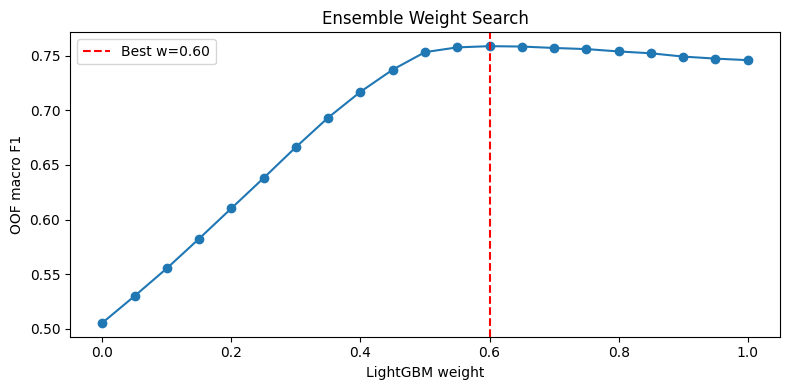

Best LGB weight: 0.60  →  OOF macro F1 = 0.75862

Ensemble Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.95      0.95    114173
           1       0.70      0.79      0.74     15918
           2       0.84      0.85      0.85     62440
           3       0.51      0.47      0.49      5469

    accuracy                           0.89    198000
   macro avg       0.75      0.76      0.76    198000
weighted avg       0.89      0.89      0.89    198000



In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# ENSEMBLE — grid search blend weight
# ══════════════════════════════════════════════════════════════════════════════

best_score, best_w = 0, 0.5
results = []
for w in np.arange(0.0, 1.01, 0.05):
    blend = w * oof_lgb + (1 - w) * oof_lr
    score = f1_score(y, blend.argmax(1), average='macro')
    results.append((w, score))
    if score > best_score:
        best_score, best_w = score, w

ws, ss = zip(*results)
plt.figure(figsize=(8, 4))
plt.plot(ws, ss, marker='o')
plt.axvline(best_w, color='red', linestyle='--', label=f'Best w={best_w:.2f}')
plt.xlabel('LightGBM weight')
plt.ylabel('OOF macro F1')
plt.title('Ensemble Weight Search')
plt.legend(); plt.tight_layout(); plt.show()

print(f'Best LGB weight: {best_w:.2f}  →  OOF macro F1 = {best_score:.5f}')
print('\nEnsemble Classification Report:')
print(classification_report(y, (best_w * oof_lgb + (1-best_w) * oof_lr).argmax(1)))

In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# FULL RETRAIN + SUBMISSION
# ══════════════════════════════════════════════════════════════════════════════

best_n = max(int(np.mean(best_iters) * 1.05), 100)
print(f'Full retrain LightGBM: n_estimators={best_n}')

lgb_full = lgb.LGBMClassifier(**{**lgb_params, 'n_estimators': best_n})
lgb_full.fit(X_full_train, y, callbacks=[lgb.log_evaluation(200)])
test_lgb_full = lgb_full.predict_proba(X_full_test)

print('Full retrain LR...')
lr_full = LogisticRegression(
    C=3.0, max_iter=1000, solver='lbfgs',
    class_weight='balanced', random_state=42,
    multi_class='multinomial', n_jobs=-1
)
lr_full.fit(X_svd_train_s, y)
test_lr_full = lr_full.predict_proba(X_svd_test_s)

# Final predictions
test_blend = best_w * test_lgb_full + (1 - best_w) * test_lr_full
test_preds = test_blend.argmax(1)

print('\nTest prediction distribution:')
unique, counts = np.unique(test_preds, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Label {u}: {c:,} ({c/len(test_preds)*100:.1f}%)')

submission = sample.copy()
submission['label'] = test_preds
submission.to_csv('submission.csv', index=False)

print(f'\n✅ submission.csv saved | Shape: {submission.shape}')
print(submission.head())

print('\n' + '='*60)
print('FINAL RESULTS SUMMARY')
print('='*60)
print(f'  LightGBM (GPU) OOF macro F1  : {lgb_oof_score:.5f}')
print(f'  LR (SVD text)  OOF macro F1  : {lr_oof_score:.5f}')
print(f'  Ensemble OOF macro F1        : {best_score:.5f}  (LGB w={best_w:.2f})')
print('='*60)
print(f'  Baseline (LB)                : 0.65656')
print('='*60)

Full retrain LightGBM: n_estimators=208
Full retrain LR...

Test prediction distribution:
  Label 0: 57,580 (56.5%)
  Label 1: 9,217 (9.0%)
  Label 2: 32,287 (31.7%)
  Label 3: 2,916 (2.9%)

✅ submission.csv saved | Shape: (102000, 2)
   ID  label
0   1      2
1   2      2
2   3      0
3   4      0
4   5      2

FINAL RESULTS SUMMARY
  LightGBM (GPU) OOF macro F1  : 0.74583
  LR (SVD text)  OOF macro F1  : 0.50544
  Ensemble OOF macro F1        : 0.75862  (LGB w=0.60)
  Baseline (LB)                : 0.65656
